In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("df.pck")
df.head()

,token,z_score,topic,prompt_condition,model,moral,matched_word,polarity
24,appealing,2.150933,mental-health,base,Apertus-8B-Instruct-2509,authority.virtue,appealing,virtue
29,promotes,3.031657,mental-health,base,Apertus-8B-Instruct-2509,sanctity.virtue,promote,virtue
46,giving,2.053795,mental-health,base,Apertus-8B-Instruct-2509,fairness.virtue,giving,virtue
160,reson,2.269640,mental-health,care,Apertus-8B-Instruct-2509,None,None,None
176,showing,3.323242,mental-health,care,Apertus-8B-Instruct-2509,fairness.vice,showing,vice


In [3]:
crosstabs = defaultdict(dict)

prompt_conditions = sorted(df["prompt_condition"].unique())
model = "Apertus-8B-Instruct-2509"
for model in sorted(df["model"].unique()):
    crosstabs[model] = defaultdict(dict)
    df_m = df[df["model"] == model]
    prompt = "base"
    for prompt in prompt_conditions:
        df_mp = df_m[df_m["prompt_condition"] == prompt]

        crosstabs[model][prompt] = pd.crosstab(
            df_mp["topic"],
            df_mp["polarity"],
            normalize="index",    
        ).reindex(columns=["virtue", "vice"], fill_value=0)

In [12]:
models2show = ['Apertus-8B-Instruct-2509',
  'Llama-3.2-1B-Instruct',
 'Llama-3.2-3B-Instruct',
 'Llama-3.1-8B-Instruct',
 'Llama-3.1-70B-Instruct',
  'Qwen2.5-7B-Instruct',
 'Qwen2.5-14B-Instruct',
 'Qwen2.5-72B-Instruct',
]

In [13]:
prompt_conditions = sorted(df["prompt_condition"].unique())
prompt_conditions.remove("base")

differences = defaultdict(dict)
for model in models2show:
    differences[model] = defaultdict(dict)
    for prompt in prompt_conditions:
        differences[model][prompt] = np.abs(crosstabs[model][prompt]["virtue"] - crosstabs[model]["base"]["virtue"])

differences = pd.concat(
    {outer: pd.DataFrame(inner) for outer, inner in differences.items()},
    axis=1
)
differences.columns.names = ["model", "moral"]
differences.loc["Mean", :] = differences.mean(axis=0)

In [ ]:
table.columns = ['Apertus-8B', 'Llama-3.2-1B', 'Llama-3.2-3B', 'Llama-3.1-8B', 'Llama-3.1-70B',
                 'Qwen2.5-7B', 'Qwen2.5-14B', 'Qwen2.5-72B']


Index(['Apertus-8B-Instruct-2509', 'Llama-3.2-1B-Instruct',
       'Llama-3.2-3B-Instruct', 'Llama-3.1-8B-Instruct',
       'Llama-3.1-70B-Instruct', 'Qwen2.5-7B-Instruct', 'Qwen2.5-14B-Instruct',
       'Qwen2.5-72B-Instruct'],
      dtype='object', name='model')

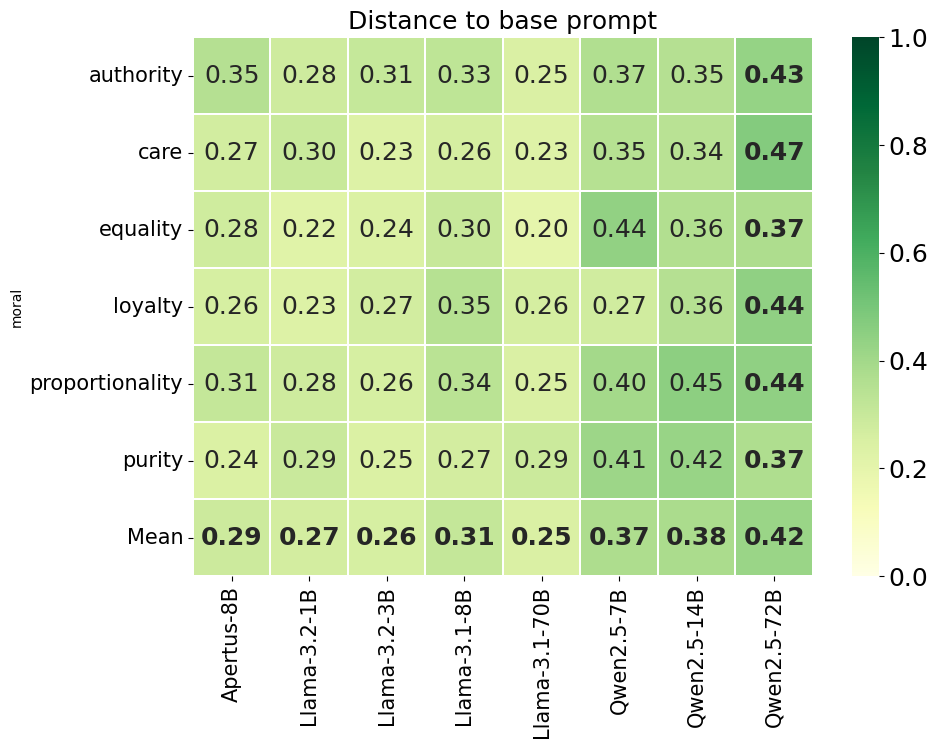

In [38]:
table = differences.loc["Mean"].reset_index().pivot(index="moral", columns="model", values="Mean")
table["Mean"] = table.mean(axis=1)
table.loc["Mean", :] = table.mean(axis=0)
table = table.loc[:, models2show]
table.columns = ['Apertus-8B', 'Llama-3.2-1B', 'Llama-3.2-3B', 'Llama-3.1-8B', 'Llama-3.1-70B',
                 'Qwen2.5-7B', 'Qwen2.5-14B', 'Qwen2.5-72B']

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(
    table,
    annot=True,
    fmt=".2f",
    cmap="YlGn",            
    vmin=0, vmax=1,
    linewidths=0.3,
    annot_kws={"size": 18})
col = -1
for idx in np.arange(table.size).reshape(table.shape)[:, col]:
    ax.texts[idx].set_fontweight('bold')
row = -1
for idx in np.arange(table.size).reshape(table.shape)[row, :]:
    ax.texts[idx].set_fontweight('bold')
plt.title("Distance to base prompt", fontsize=18)
ax.tick_params(axis='both', labelsize=15)
ax.tick_params(axis='y', labelrotation=0)
ax.figure.axes[-1].tick_params(labelsize=18)
plt.savefig(f"../charts/entropy/high_zcore_moral_distance_to_base_prompt.pdf", format="pdf", bbox_inches="tight")